# Demo 1 — Oja's rule learns the top principal component

**Tutorial:** *Synaptic Plasticity and Learning* (CCNSS2026) · Lecture 1

**Idea.** Plain Hebbian learning $\dot w = \eta\, y\,x$ is unstable — weights grow without
bound. **Oja's rule** adds a normalization term:

$$\Delta w = \eta\, y\,(x - y\,w), \qquad y = w^\top x$$

The subtracted $y^2 w$ keeps $\|w\|\to 1$ and, on average, drives $w$ to the **leading
eigenvector of the input covariance** — i.e. Oja is *online PCA* with a single, local,
Hebbian-plus-decay update. We verify this twice: a 2-D cloud (geometry) and image
patches (a learned filter).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110


## Part A — 2-D intuition\nAn anisotropic Gaussian cloud has one clear long axis. Oja should find it.

In [2]:
theta = np.deg2rad(30)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
X = (rng.standard_normal((4000, 2)) @ np.diag([3.0, 1.0])) @ R.T
X -= X.mean(0)

C = np.cov(X.T)
evals, evecs = np.linalg.eigh(C)
true_pc = evecs[:, np.argmax(evals)]
print("true top PC:", np.round(true_pc, 3))


true top PC: [-0.873 -0.488]


**Oja's rule** as an online loop. We track alignment with the true top PC.

In [3]:
def oja(X, lr=0.01, w0=None, ref=None):
    """Online Oja's rule. Returns final unit weight vector and (optional) alignment trace."""
    w = rng.standard_normal(X.shape[1]) if w0 is None else w0.copy()
    w /= np.linalg.norm(w)
    cosines = []
    for x in X:
        y = w @ x
        w = w + lr * y * (x - y * w)          # Hebb (y*x) + normalization (-y^2 w)
        if ref is not None:
            cosines.append(abs(w @ ref) / np.linalg.norm(w))
    return w, np.array(cosines)

w2d, cos2d = oja(X, lr=0.01, ref=true_pc)
print("final |cos(w, true_pc)| =", round(cos2d[-1], 4), " |w| =", round(np.linalg.norm(w2d), 4))


final |cos(w, true_pc)| = 0.9991  |w| = 1.0015


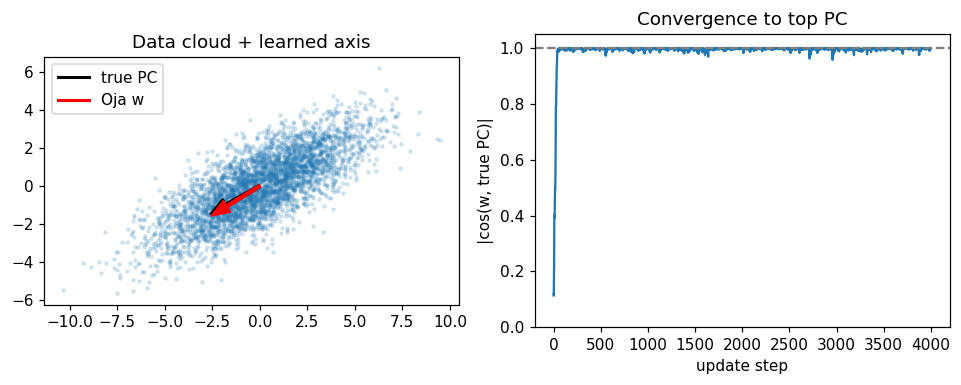

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
ax[0].scatter(X[:, 0], X[:, 1], s=4, alpha=0.15)
for vec, c, lab in [(true_pc, "k", "true PC"), (w2d/np.linalg.norm(w2d), "r", "Oja w")]:
    ax[0].annotate("", xy=3*vec, xytext=(0, 0),
                   arrowprops=dict(color=c, width=2, headwidth=9))
    ax[0].plot([], [], color=c, lw=2, label=lab)
ax[0].set_aspect("equal"); ax[0].legend(); ax[0].set_title("Data cloud + learned axis")
ax[1].plot(cos2d); ax[1].axhline(1, ls="--", c="gray")
ax[1].set_xlabel("update step"); ax[1].set_ylabel("|cos(w, true PC)|")
ax[1].set_title("Convergence to top PC"); ax[1].set_ylim(0, 1.05)
plt.tight_layout(); plt.show()


## Part B — Image patches: Oja learns a filter

A single Oja neuron viewing small image patches learns the patch ensemble's **top
principal component** — a spatial filter. We use $1/f$ ("pink-noise") imagery as a
stand-in for natural-image statistics, then check the learned filter against scikit-learn's
PCA. *(Note: the top PC of natural images is a smooth, low-frequency pattern — not an
oriented Gabor. Oriented, sparse receptive fields require ICA/sparse coding, which is
exactly what Demo 2's Error-Gated Hebbian Rule delivers.)*


In [5]:
def pink_image(n, beta=1.5):
    f = np.fft.fftfreq(n); fx, fy = np.meshgrid(f, f)
    r = np.sqrt(fx**2 + fy**2); r[0, 0] = 1.0
    phase = np.exp(2j * np.pi * rng.random((n, n)))
    img = np.fft.ifft2((1.0 / r**beta) * phase).real
    return (img - img.mean()) / img.std()

P, N = 12, 6000
big = pink_image(256)
idx = rng.integers(0, 256 - P, size=(N, 2))
patches = np.array([big[i:i+P, j:j+P].ravel() for i, j in idx])
patches -= patches.mean(0)

top_pc = PCA(n_components=1).fit(patches).components_[0]
w_img, _ = oja(patches, lr=0.002, w0=rng.standard_normal(P*P))
w_img /= np.linalg.norm(w_img)
print("|cos(Oja filter, sklearn top PC)| =", round(abs(w_img @ top_pc), 4))


|cos(Oja filter, sklearn top PC)| = 0.9904


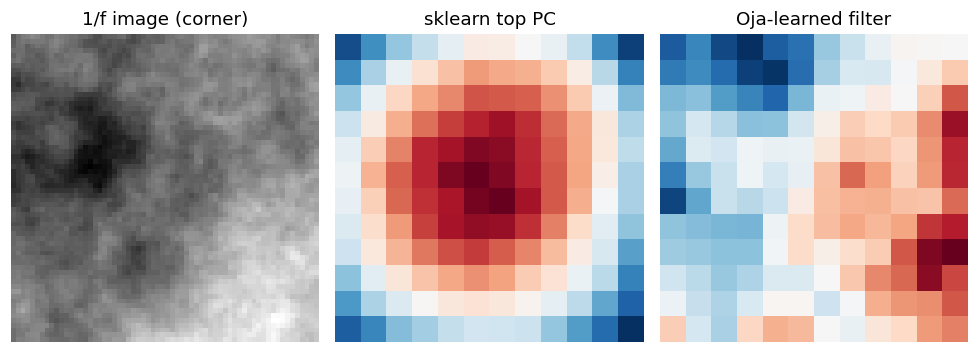

In [6]:
# align sign for display
if w_img @ top_pc < 0:
    w_img = -w_img
fig, ax = plt.subplots(1, 3, figsize=(9, 3.2))
ax[0].imshow(big[:64, :64], cmap="gray"); ax[0].set_title("1/f image (corner)")
ax[1].imshow(top_pc.reshape(P, P), cmap="RdBu_r"); ax[1].set_title("sklearn top PC")
ax[2].imshow(w_img.reshape(P, P), cmap="RdBu_r"); ax[2].set_title("Oja-learned filter")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()


## Takeaways

- **Oja = Hebb + normalization = online PCA.** A single, *local* synaptic rule extracts the
  direction of maximal variance — no batch eigensolver needed.
- The learned filter matches the analytic top PC (cosine ≈ 1).
- **Bridge to Lecture 2:** variance/PCA is one objective. What if the *right* objective is
  **maximizing information**? That yields richer, sparser, more biological features — and a
  *local* rule to learn them (the **Error-Gated Hebbian Rule**, Demo 2).
